<a href="https://colab.research.google.com/github/Omar-RojasGBF/lis5693/blob/main/lab-3/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import altair as alt
from vega_datasets import data as vega_data

In [2]:
import requests
import io

url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-3/Seattle-Library_2015-2021.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

In [3]:
seattle_df = pd.read_csv(io.StringIO(text))
seattle_df.head()

,Title,Creator,MaterialType,Checkouts,CheckoutYear,CheckoutMonth,Publisher,PublicationYear,Subjects,UsageClass,CheckoutType
0,Frog and toad all year / by Arnold Lobel.,"Lobel, Arnold",BOOK,34,2016,10,"Harper & Row,",c1976.,"Friendship Fiction, Frogs Juvenile fiction, To...",Physical,Horizon
1,"My brilliant friend : childhood, adolescence /...","Ferrante, Elena",BOOK,110,2016,10,"Europa Editions,",2012,"Friendship Fiction, Naples Italy Fiction",Physical,Horizon
2,Star trek [videorecording] / Paramount ; Spygl...,NaN,VIDEODISC,36,2016,10,"Paramount Home Entertainment,",c2009.,"Kirk James T 2233 2371 Drama, Spock Mr Drama, ...",Physical,Horizon
3,The Man in the High Castle,Philip K. Dick,EBOOK,63,2016,10,Houghton Mifflin Harcourt Trade and Reference,2012,"Fiction, Science Fiction",Digital,OverDrive
4,"The Fifth Season: Broken Earth Series, Book 1",N. K. Jemisin,EBOOK,44,2016,10,"Hachette Digital, Inc.",2015,"Fantasy, Fiction, Thriller",Digital,OverDrive


<Axes: xlabel='CheckoutYear'>

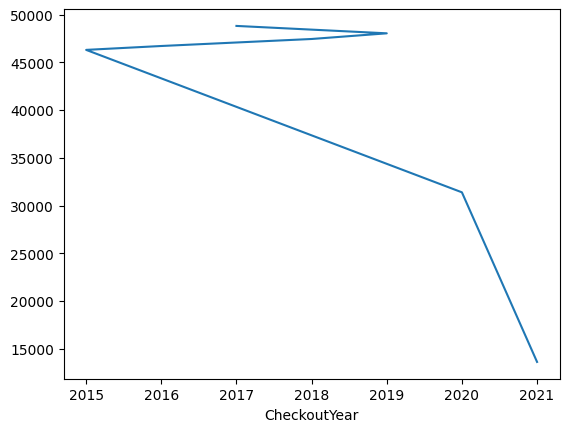

In [31]:
seattle_df['CheckoutYear'].value_counts().plot(kind='line')

In [35]:
seattle_df['MaterialType'].value_counts().plot(kind='arc')

ValueError: arc is not a valid plot kind Valid plot kinds: ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')

In [32]:
seattle_df['CheckoutYear'].value_counts()

,count
CheckoutYear,
2017,48807
2019,48032
2018,47439
2016,46705
2015,46298
2020,31383
2021,13623


In [36]:
seattle_df['MaterialType'].value_counts()

,count
MaterialType,
BOOK,102076
VIDEODISC,74473
EBOOK,57299
AUDIOBOOK,34542
SOUNDDISC,6593
MAGAZINE,4197
SONG,975
MOVIE,596
REGPRINT,447


In [37]:
type(seattle_df['CheckoutYear'].value_counts())

pandas.core.series.Series

In [38]:
type(seattle_df['MaterialType'].value_counts())

pandas.core.series.Series

In [39]:
seattle_df['CheckoutYear'].value_counts().rename_axis('CheckoutYear').reset_index(name='counts')

,CheckoutYear,counts
0,2017,48807
1,2019,48032
2,2018,47439
3,2016,46705
4,2015,46298
5,2020,31383
6,2021,13623


In [40]:
seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')

,MaterialType,counts
0,BOOK,102076
1,VIDEODISC,74473
2,EBOOK,57299
3,AUDIOBOOK,34542
4,SOUNDDISC,6593
5,MAGAZINE,4197
6,SONG,975
7,MOVIE,596
8,REGPRINT,447
9,MUSIC,382


In [42]:
source = seattle_df['CheckoutYear'].value_counts().rename_axis('CheckoutYear').reset_index(name='counts')
alt.Chart(source).mark_line().encode(
    x='CheckoutYear',
    y='counts'
)

alt.Chart(...)

In [43]:
source = seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')
alt.Chart(source).mark_point().encode(
    x='MaterialType',
    y='counts'
)

alt.Chart(...)

In [44]:
source = seattle_df['CheckoutYear'].value_counts().rename_axis('CheckoutYear').reset_index(name='counts')
alt.Chart(source).mark_line().encode(
    x=alt.X('CheckoutYear', sort='-y'),
    y='counts'
)

alt.Chart(...)

In [45]:
source = seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')
alt.Chart(source).mark_point().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts'
)

alt.Chart(...)

In [62]:
alt.Chart(seattle_df).mark_point().encode(
     x=alt.X('CheckoutYear', sort='-y'),
     y='count()',
     color='CheckoutMonth:N'
 )

MaxRowsError: The number of rows in your dataset is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.Chart(...)

In [63]:
alt.data_transformers.enable("vegafusion")
alt.Chart(seattle_df).mark_point().encode(
     x=alt.X('MaterialType', sort='-y'),
     y='count()',
     color='CheckoutYear:N'
 )

MaxRowsError: The number of rows in your dataset is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.Chart(...)

In [48]:
seattle_material_grouped = seattle_df.groupby(['CheckoutYear', 'CheckoutMonth']).size().reset_index(name='counts')
alt.Chart(seattle_material_grouped).mark_line().encode(
    x=alt.X('CheckoutYear', sort='-y'),
    y='counts',
    color='CheckoutMonth:N'
)

alt.Chart(...)

In [49]:
seattle_material_grouped = seattle_df.groupby(['MaterialType', 'CheckoutYear']).size().reset_index(name='counts')
alt.Chart(seattle_material_grouped).mark_point().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color='CheckoutYear:N'
)

alt.Chart(...)

In [67]:
alt.Chart(seattle_material_grouped).mark_line().encode(
    x=alt.X('CheckoutYear', sort='-y'),
    y='counts',
    color='CheckoutMonth:N',
    tooltip=['CheckoutYear', 'counts', 'CheckoutMonth']
).interactive()

ValueError: Unable to determine data type for the field "CheckoutMonth"; verify that the field name is not misspelled. If you are referencing a field from a transform, also confirm that the data type is specified correctly.

alt.Chart(...)

In [51]:
alt.Chart(seattle_material_grouped).mark_point().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color='CheckoutYear:N',
    tooltip=['MaterialType', 'counts', 'CheckoutYear']
).interactive()

alt.Chart(...)

In [55]:
selection = alt.selection_point(fields=['CheckoutMonth'], bind='legend')
alt.Chart(seattle_material_grouped).mark_line().encode(
    x=alt.X('CheckoutYear', sort='-y'),
    y='counts',
    color=alt.Color('CheckoutMonth:N', sort=alt.EncodingSortField('CheckoutMonth', order='descending')),
    tooltip=['CheckoutYear', 'counts', 'CheckoutMonth'],
    opacity=alt.condition(selection, alt.value(1), alt.value(0.2)),
    order='CheckoutMonth'
).add_params(
    selection
)

ValueError: Unable to determine data type for the field "CheckoutMonth"; verify that the field name is not misspelled. If you are referencing a field from a transform, also confirm that the data type is specified correctly.

alt.Chart(...)

In [56]:
selection = alt.selection_point(fields=['CheckoutYear'], bind='legend')
alt.Chart(seattle_material_grouped).mark_point().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color=alt.Color('CheckoutYear:N', sort=alt.EncodingSortField('CheckoutYear', order='descending')),
    tooltip=['MaterialType', 'counts', 'CheckoutYear'],
    opacity=alt.condition(selection, alt.value(1), alt.value(0.2)),
    order='CheckoutYear'
).add_params(
    selection
)

alt.Chart(...)

Reflection 💭


---
This was probably one of my most frusterating labs yet. Given that I already have experience with using R for data visualizations, I was under the wrong impression that creating these charts would be easy. When it came to adding interactivity to my graphs, my scatter plot for the Material Type had no issues, but my line graph for the Checkout Years only gave me errors.
